In [93]:
!pip install shap --quiet

In [94]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score, roc_auc_score, confusion_matrix,
ConfusionMatrixDisplay, roc_curve, classification_report
)
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [95]:
#file path for connect csv file ( database )
credit_df_original = pd.read_csv('/content/Credit_Card.csv',sep =';')

credit_df = credit_df_original.copy()

credit_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64
0 = No Default
1 = Default


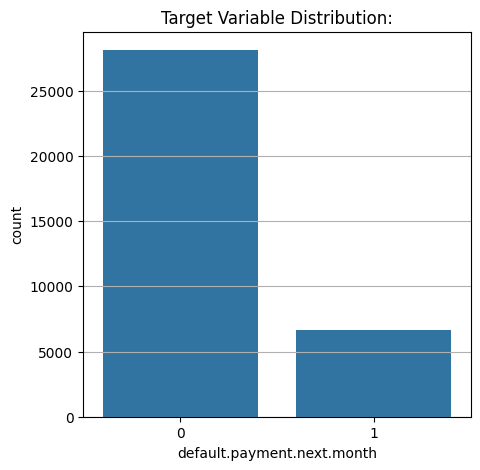

In [96]:
#target variable

print(credit_df['default.payment.next.month'].value_counts())
print(credit_df['default.payment.next.month'].value_counts(normalize=True) * 100)
plt.figure(figsize=(5, 5))
sns.countplot(x='default.payment.next.month', data=credit_df)
plt.title('Target Variable Distribution:')
print('0 = No Default')
print('1 = Default')
plt.show()

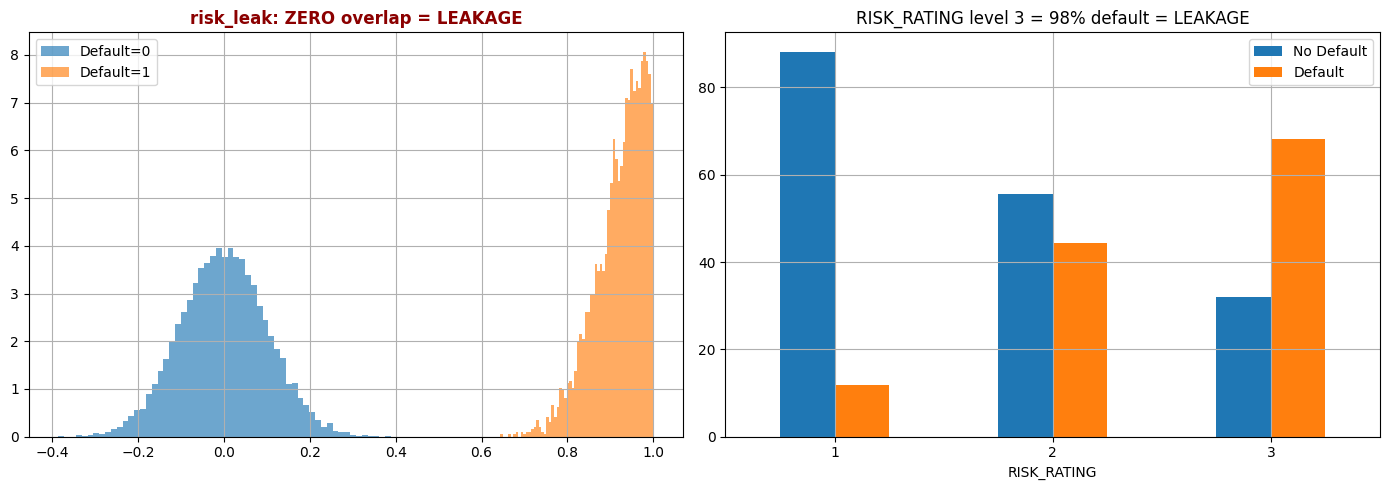

Both columns removed before any modelling


In [97]:
# Data leakage
data_leak = pd.to_numeric(credit_df['risk_leak'], errors='coerce')
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for label, grp in credit_df.groupby('default.payment.next.month'):
    axes[0].hist(data_leak[grp.index].dropna(), bins=60, alpha=0.65,
                 density=True, label=f'Default={int(label)}')
axes[0].set_title('risk_leak: ZERO overlap = LEAKAGE', color='darkred', fontweight='bold')
axes[0].legend()
cross = pd.crosstab(credit_df['RISK_RATING'],credit_df['default.payment.next.month'], normalize='index')*100
cross.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('RISK_RATING level 3 = 98% default = LEAKAGE')
axes[1].legend(['No Default','Default'])
plt.tight_layout(); plt.show()
print('Both columns removed before any modelling')


In [98]:
#Descriptive
desc_col = ['LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','PAY_AMT1','PAY_0']
desc = credit_df[desc_col].describe().T[['mean','50%','std','min','max']]
desc.columns = ['Mean','Median','Std','Min','Max']
print(desc.round(2).to_string())

                Mean    Median        Std       Min        Max
LIMIT_BAL  184668.99  140000.0  235931.93   10000.0  5600000.0
AGE            35.52      34.0       9.24      21.0       79.0
BILL_AMT1   51312.96   22626.0   73407.50 -165580.0   964511.0
BILL_AMT2   49271.12   21458.5   71090.42  -69777.0   983931.0
PAY_AMT1     5772.82    2160.0   16917.88       0.0   873552.0
PAY_0          -0.05       0.0       1.10      -2.0        8.0


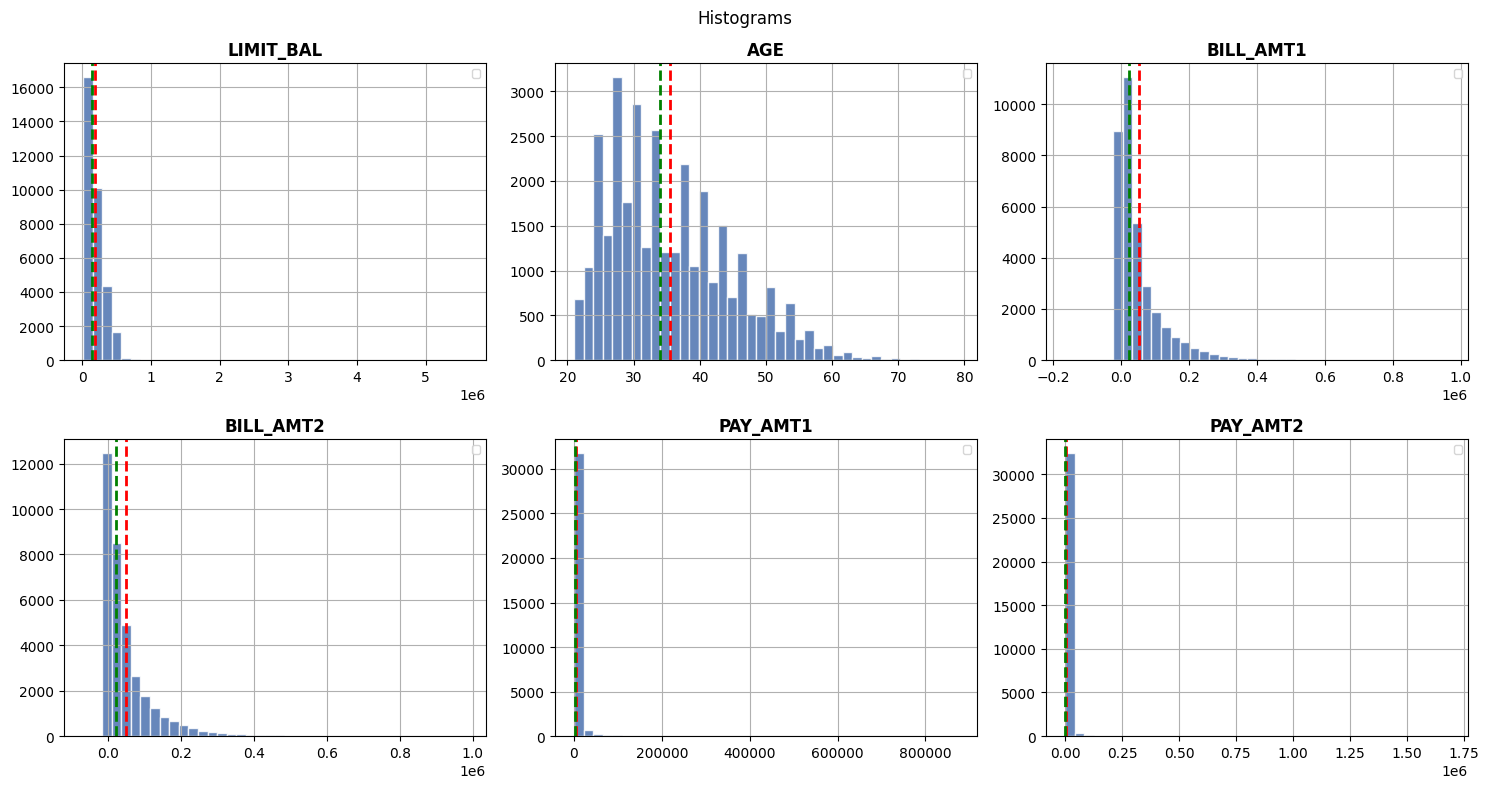

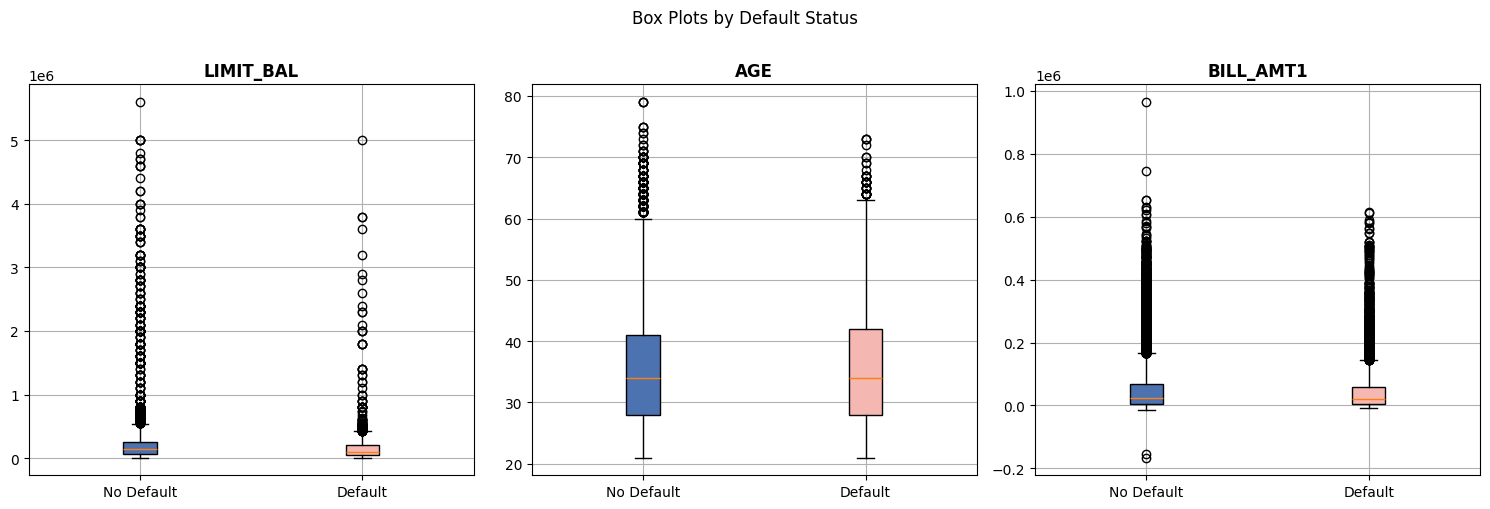

In [99]:
import matplotlib.pyplot as plt

hist_col = ['LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','PAY_AMT1','PAY_AMT2']
box_col = ['LIMIT_BAL','AGE','BILL_AMT1']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i , col in enumerate(hist_col) :
    d = credit_df[col].dropna()
    axes[i].hist(d, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].axvline(d.mean(), color='red', linestyle='dashed', linewidth=2)
    axes[i].axvline(d.median(), color='green', linestyle='dashed', linewidth=2)
    axes[i].set_title(col, fontweight='bold');
    axes[i].legend(fontsize=8)
plt.suptitle("Histograms")
plt.tight_layout();
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes = axes.flatten()
for i , col in enumerate(box_col) :
    d0 = credit_df[credit_df['default.payment.next.month']==0][col].dropna()
    d1 = credit_df[credit_df['default.payment.next.month']==1][col].dropna()
    bp = axes[i].boxplot([d0,d1], labels=['No Default','Default'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4C72B0');
    bp['boxes'][1].set_facecolor('#F5B7B1');
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Box Plots by Default Status', y=1.01)
plt.tight_layout();
plt.show()


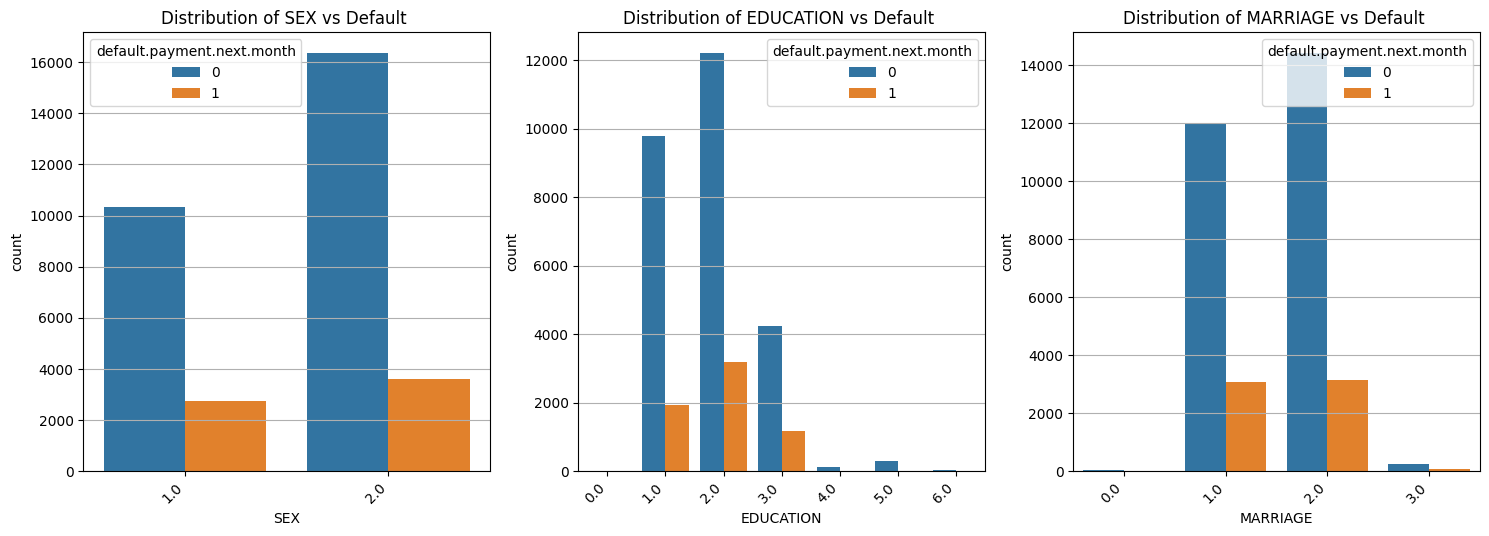

SEX: 1=Male, 2=Female
EDUCATION: 1=Graduate, 2=University, 3=High School, 4=Other
MARRIAGE: 1=Married, 2=Single, 3=Other


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
cate_fe_cols = ['SEX','EDUCATION','MARRIAGE']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cate_fe_cols):
  plt.subplot(2,3,i+1)
  sns.countplot(x=col,hue='default.payment.next.month',data=credit_df)
  plt.title(f'Distribution of {col} vs Default ')
  plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
print('SEX: 1=Male, 2=Female')
print('EDUCATION: 1=Graduate, 2=University, 3=High School, 4=Other')
print('MARRIAGE: 1=Married, 2=Single, 3=Other')

Top correlations with default (leakage excluded):
PAY_0        0.314
PAY_2        0.254
PAY_3        0.225
PAY_4        0.208
PAY_5        0.196
PAY_6        0.179
LIMIT_BAL   -0.090
PAY_AMT1    -0.069
PAY_AMT3    -0.053
PAY_AMT4    -0.053


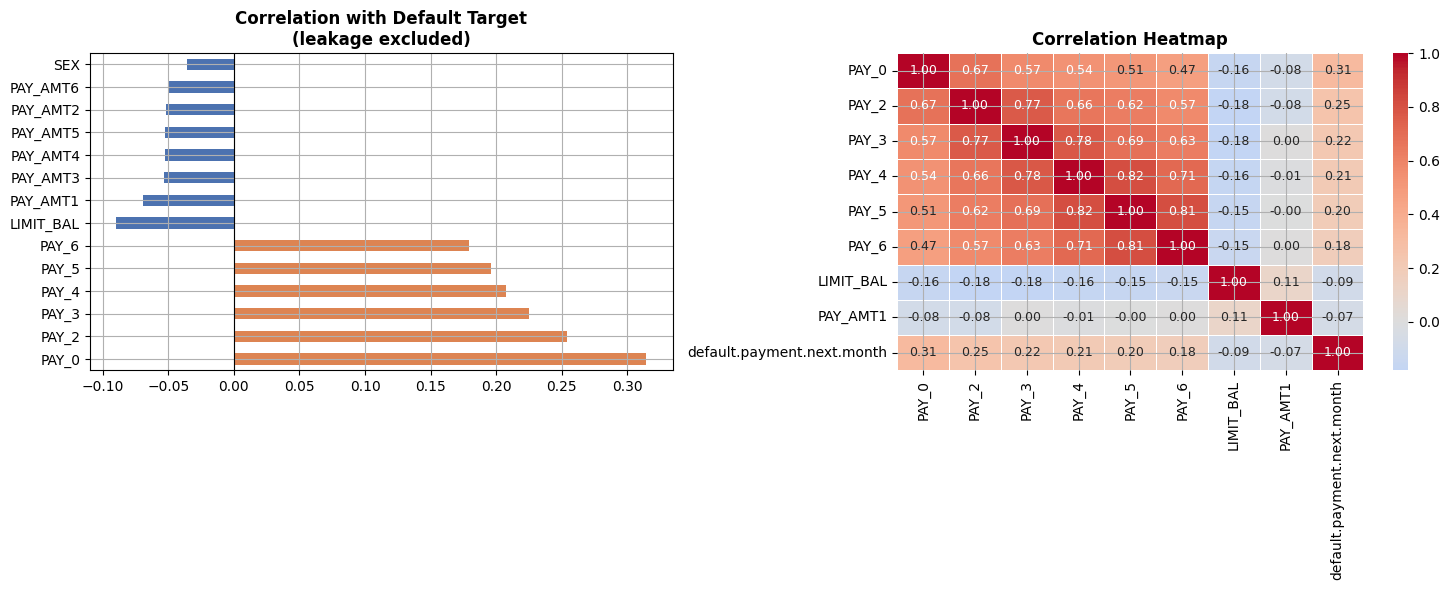

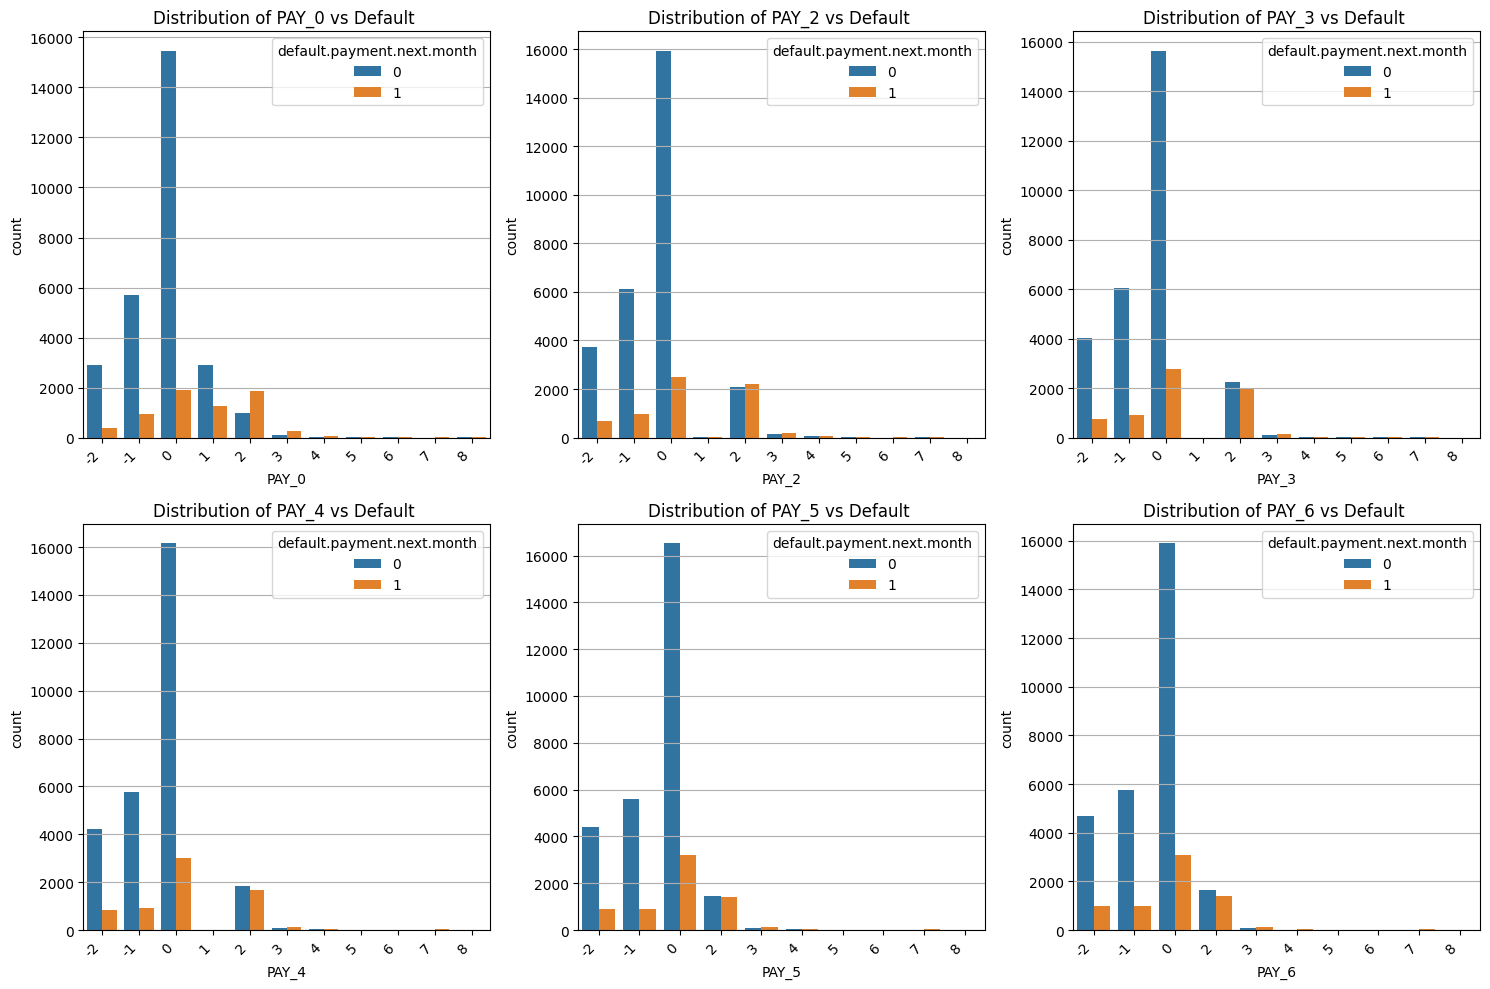

In [101]:
exclude = ['risk_leak','RISK_RATING','ID','BILL_AMT_SUM','LIMIT_BAL_LOG','CITY']
clean_cols = [c for c in credit_df.select_dtypes(include=[np.number]).columns if c not in exclude]
corr = (credit_df[clean_cols].corr()['default.payment.next.month']
        .drop('default.payment.next.month').sort_values(key=abs, ascending=False))

print('Top correlations with default (leakage excluded):')
print(corr.head(10).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15,6))
colors = ['#DD8452' if v>0 else '#4C72B0' for v in corr.head(14).values]
corr.head(14).plot(kind='barh', ax=axes[0], color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Correlation with Default Target\n(leakage excluded)', fontweight='bold')
top = corr.head(8).index.tolist() + ['default.payment.next.month']
sns.heatmap(credit_df[top].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], linewidths=0.5, annot_kws={'size':9})
axes[1].set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout();
plt.show()

payment_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
plt.figure(figsize=(15, 10))
for i, col in enumerate(payment_cols):
  plt.subplot(2,3,i+1)
  sns.countplot(x=col,hue='default.payment.next.month',data=credit_df)
  plt.title(f'Distribution of {col} vs Default ')
  plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [102]:
credit_df.head()
#Task - 2
col_drop = ['ID','CITY','risk_leak','BILL_AMT_SUM','LIMIT_BAL_LOG','RISK_RATING']
credit_credit_df = credit_df.drop(columns=col_drop)
print(f'Dropped {len(col_drop)} columns. New shape: {credit_credit_df.shape}')
print("Shape:", credit_credit_df.shape)
print("\nNumber of duplicate rows:", credit_credit_df.duplicated().sum())

credit_credit_df['EDUCATION'] = credit_credit_df['EDUCATION'].replace({0:4, 5:4, 6:4})
credit_credit_df['MARRIAGE']  = credit_credit_df['MARRIAGE'].replace({0:3})
print('Fixed undocumented codes in EDUCATION and MARRIAGE')


Dropped 6 columns. New shape: (34788, 24)
Shape: (34788, 24)

Number of duplicate rows: 4804
Fixed undocumented codes in EDUCATION and MARRIAGE


In [103]:
# Missing values
missing = credit_credit_df.isnull().sum()
missing = missing[missing > 0]
pct = (missing / len(credit_credit_df) * 100).round(1)
print('Missing values per column:')
for col in missing.index:
    print(f'  {col:<20} {missing[col]:>5} rows ({pct[col]:.1f}%)')
print('\nStrategy: Median imputation (robust to right-skewed distributions)')
print('Rule: Fit imputer on training data only - not full dataset')

Missing values per column:
  LIMIT_BAL             1709 rows (4.9%)
  SEX                   1767 rows (5.1%)
  EDUCATION             1734 rows (5.0%)
  MARRIAGE              1733 rows (5.0%)
  AGE                   1755 rows (5.0%)
  PAY_AMT1              1725 rows (5.0%)
  PAY_AMT2              1744 rows (5.0%)

Strategy: Median imputation (robust to right-skewed distributions)
Rule: Fit imputer on training data only - not full dataset


In [104]:
 #target = default.payment.next.month
X = credit_credit_df.drop(columns='default.payment.next.month')
y = credit_credit_df['default.payment.next.month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(imputer.fit_transform(X_train[num_cols]))
X_test_s  = scaler.transform(imputer.transform(X_test[num_cols]))
X_train_s = pd.DataFrame(X_train_s, columns=num_cols)
X_test_s  = pd.DataFrame(X_test_s,  columns=num_cols)

print('Imputation and scaling done (fitted on training data only)')

Train shape: (27830, 23)
Test shape: (6958, 23)
Imputation and scaling done (fitted on training data only)


In [105]:
#models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5,weights='distance'),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),
}

print('Initial hyperparameters (before tuning):')
for name, model in models.items():
    print(f'  {name}: {model.get_params()}')

trained = {}
print('\nTraining...')
for name, model in models.items():
    model.fit(X_train_s, y_train)
    trained[name] = model
    print(f'  {name} done')

Initial hyperparameters (before tuning):
  Logistic Regression: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
  Decision Tree: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
  Random Forest: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 

In [106]:
results = {}
for name, model in trained.items():
    yp  = model.predict(X_test_s)
    ypr = model.predict_proba(X_test_s)[:,1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test,yp),4),
        'Precision': round(precision_score(y_test,yp,zero_division=0),4),
        'Recall':    round(recall_score(y_test,yp,zero_division=0),4),
        'F1-Score':  round(f1_score(y_test,yp,zero_division=0),4),
        'AUC-ROC':   round(roc_auc_score(y_test,ypr),4),
    }
results_df = pd.DataFrame(results).T
print('Model Performance on Test Set:')
print(results_df.to_string())

Model Performance on Test Set:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.7016     0.3430  0.6245    0.4428   0.7205
Decision Tree          0.7916     0.4450  0.3952    0.4186   0.6398
Random Forest          0.8482     0.7134  0.3354    0.4562   0.8147
K-Nearest Neighbors    0.8241     0.5634  0.3263    0.4132   0.7433
Gradient Boosting      0.8415     0.6544  0.3497    0.4558   0.7853


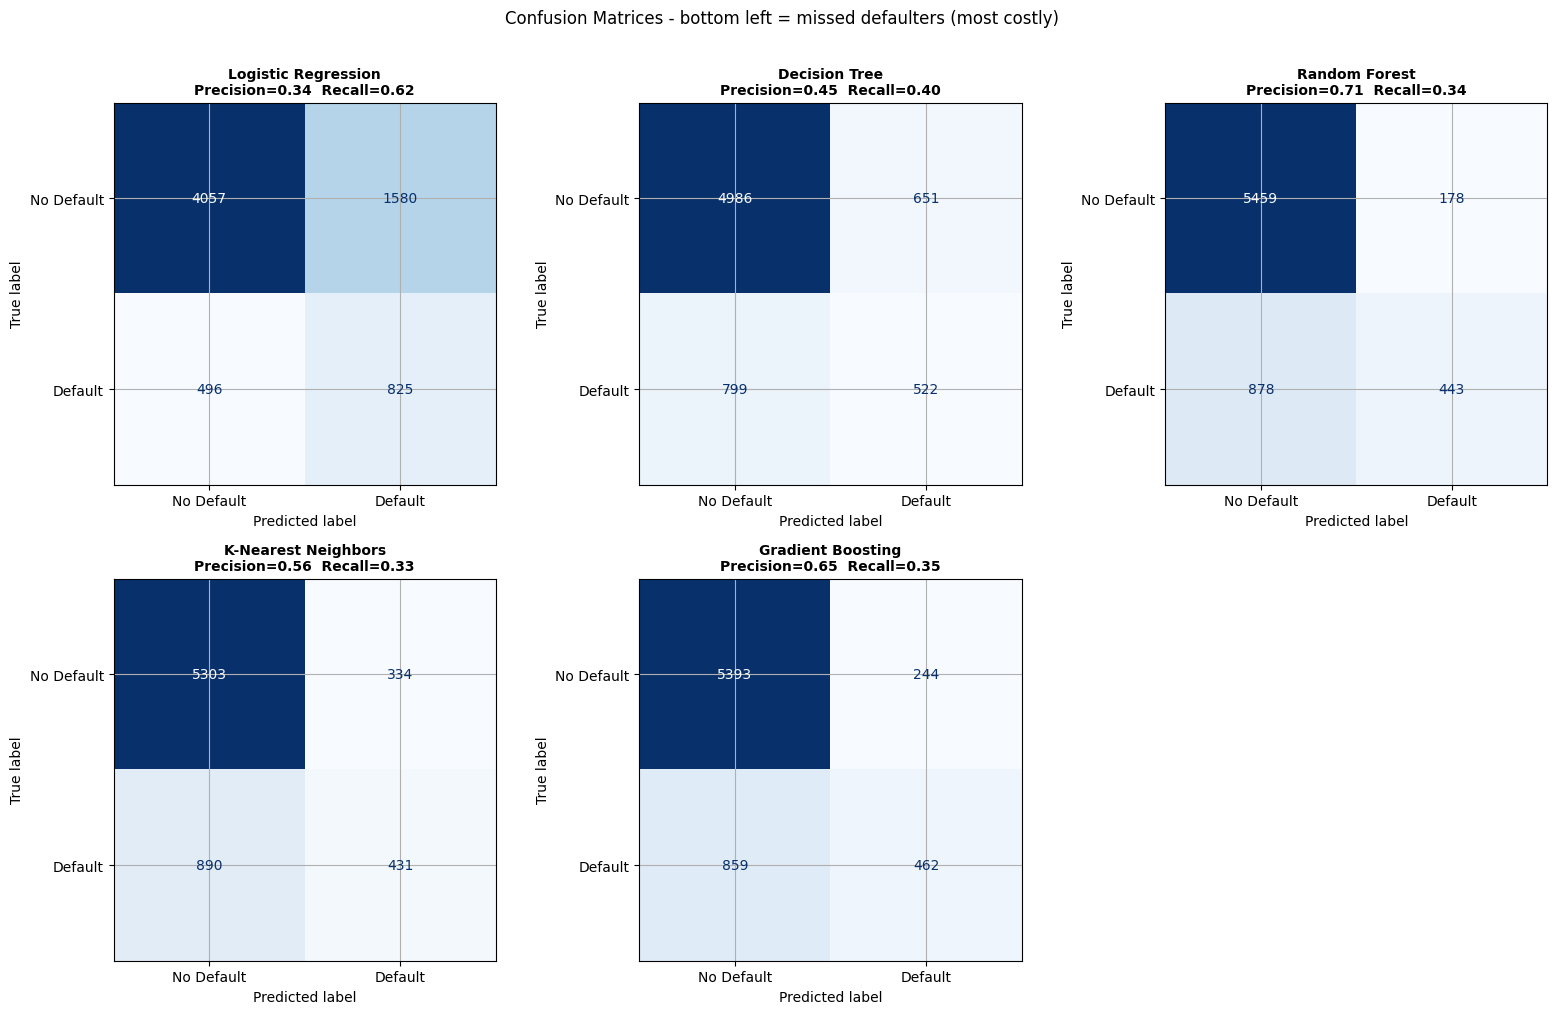

In [107]:
#Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()
for i, (name, model) in enumerate(trained.items()):
    yp = model.predict(X_test_s)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(
        ax=axes[i], cmap='Blues', colorbar=False)
    tn,fp,fn,tp2 = cm.ravel()
    axes[i].set_title(f'{name}\nPrecision={tp2/(tp2+fp):.2f}  Recall={tp2/(tp2+fn):.2f}',fontsize=10, fontweight='bold')
axes[5].set_visible(False)
plt.suptitle('Confusion Matrices - bottom left = missed defaulters (most costly)',fontsize=12, y=1.01)
plt.tight_layout();
plt.show()

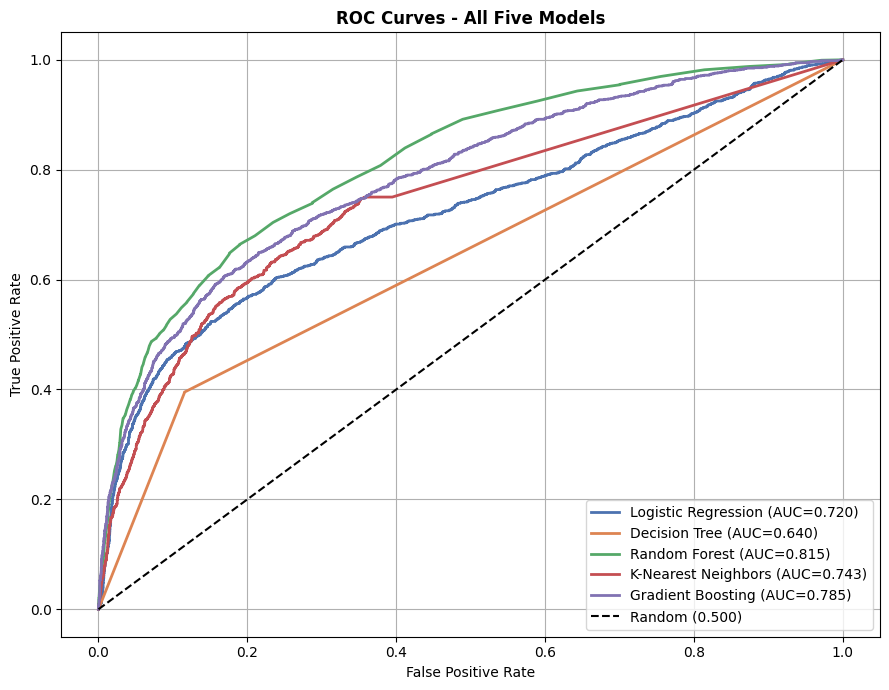

In [108]:
#ROC curves
fig, ax = plt.subplots(figsize=(9,7))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
for (name, model), col in zip(trained.items(), colors):
    ypr = model.predict_proba(X_test_s)[:,1]
    fpr,tpr,_ = roc_curve(y_test, ypr)
    auc = roc_auc_score(y_test, ypr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=col, lw=2)
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random (0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Five Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout();
plt.show()

All models ranked by AUC-ROC:
                     AUC-ROC  Recall  F1-Score
Random Forest         0.8147  0.3354    0.4562
Gradient Boosting     0.7853  0.3497    0.4558
K-Nearest Neighbors   0.7433  0.3263    0.4132
Logistic Regression   0.7205  0.6245    0.4428
Decision Tree         0.6398  0.3952    0.4186

Selected: Random Forest (AUC-ROC = 0.8147)
Reasons: highest AUC-ROC, highest accuracy, highest precision
Note: Logistic Regression has better recall (catches more defaulters)
      but lower AUC overall - trade-off depends on bank priorities


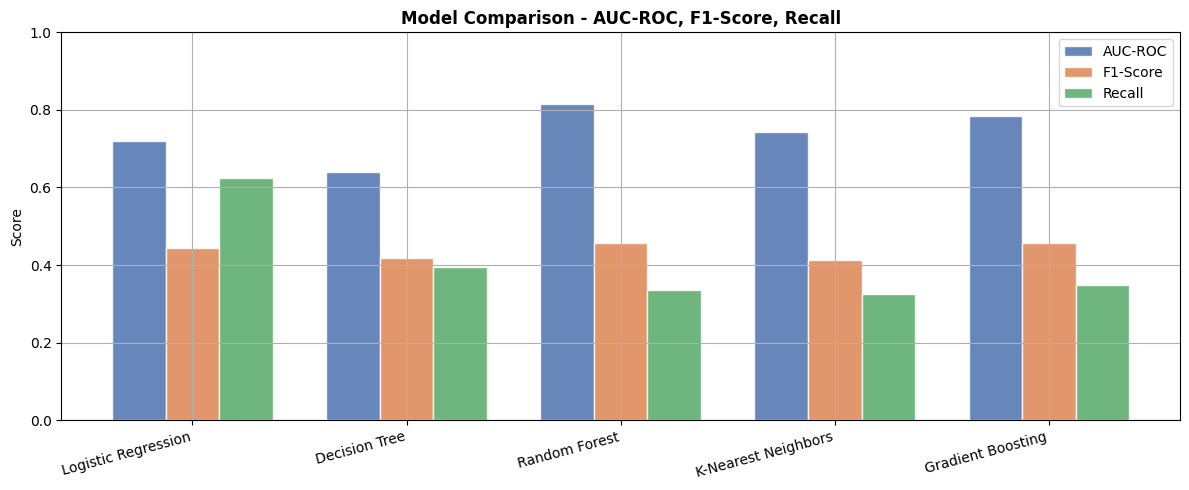

In [109]:
# Select Best model
best_name = results_df['AUC-ROC'].idxmax()
print('All models ranked by AUC-ROC:')
print(results_df.sort_values('AUC-ROC', ascending=False)[['AUC-ROC','Recall','F1-Score']].to_string())
print(f'\nSelected: {best_name} (AUC-ROC = {results_df["AUC-ROC"].max():.4f})')
print('Reasons: highest AUC-ROC, highest accuracy, highest precision')
print('Note: Logistic Regression has better recall (catches more defaulters)')
print('      but lower AUC overall - trade-off depends on bank priorities')

fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(results_df))
for j, (metric, color) in enumerate(zip(['AUC-ROC','F1-Score','Recall'],
                                          ['#4C72B0','#DD8452','#55A868'])):
    ax.bar(x + j*0.25, results_df[metric], 0.25,
           label=metric, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x+0.25); ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0,1); ax.set_ylabel('Score')
ax.set_title('Model Comparison - AUC-ROC, F1-Score, Recall', fontweight='bold')
ax.legend()
plt.tight_layout();
plt.show()

Tuning Random Forest with GridSearchCV...
This takes 3-5 minutes.
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC: 0.7811

Before: AUC=0.7853  F1=0.4558
After:  AUC=0.7866  F1=0.4619


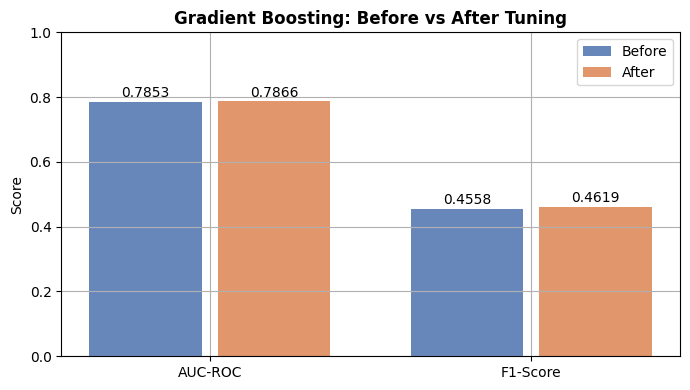

In [91]:
print(f'Tuning {best_name} with GridSearchCV...')
print('This takes 3-5 minutes.')
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(GradientBoostingClassifier(random_state=42),
                  param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train_s, y_train)
best_model = gs.best_estimator_
print(f'Best params: {gs.best_params_}')
print(f'Best CV AUC: {gs.best_score_:.4f}')

before_auc = float(results_df.loc['Gradient Boosting','AUC-ROC'])
before_f1  = float(results_df.loc['Gradient Boosting','F1-Score'])
yp_t  = best_model.predict(X_test_s)
ypr_t = best_model.predict_proba(X_test_s)[:,1]
after_auc = round(roc_auc_score(y_test, ypr_t), 4)
after_f1  = round(f1_score(y_test, yp_t), 4)
print(f'\nBefore: AUC={before_auc:.4f}  F1={before_f1:.4f}')
print(f'After:  AUC={after_auc:.4f}  F1={after_f1:.4f}')

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(2)
b1 = ax.bar(x-0.2,[before_auc,before_f1],0.35,label='Before',color='#4C72B0',alpha=0.85)
b2 = ax.bar(x+0.2,[after_auc, after_f1], 0.35,label='After', color='#DD8452',alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['AUC-ROC','F1-Score'])
ax.set_ylim(0,1); ax.set_ylabel('Score')
ax.set_title('Gradient Boosting: Before vs After Tuning', fontweight='bold')
ax.legend()
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
            f'{bar.get_height():.4f}', ha='center', fontsize=10)
plt.tight_layout();
plt.show()

Computing SHAP values...


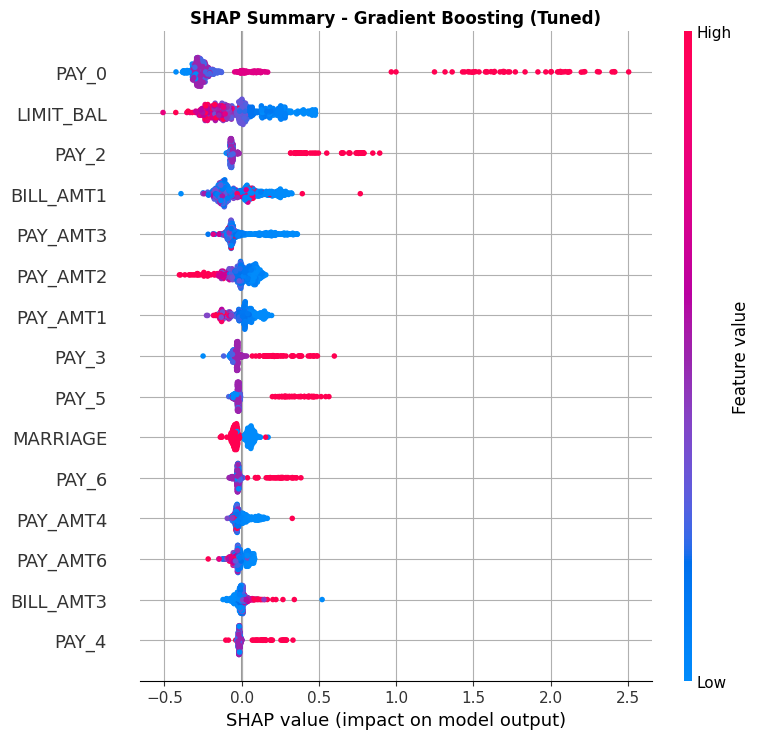

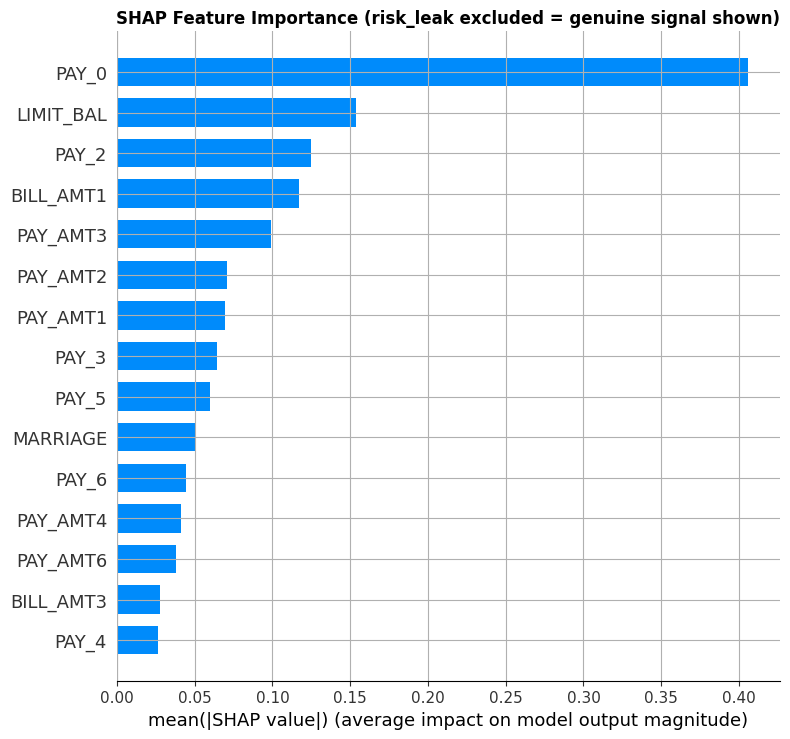

PAY_0 is the most important feature - recent payment delay = high default risk


In [92]:
print('Computing SHAP values...')
X_shap = X_test_s.sample(n=500, random_state=42)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_shap, feature_names=num_cols,
                  show=False, max_display=15)
plt.title('SHAP Summary - Gradient Boosting (Tuned)', fontweight='bold')
plt.tight_layout(); plt.show()
plt.figure(figsize=(9,6))
shap.summary_plot(shap_values, X_shap, feature_names=num_cols,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (risk_leak excluded = genuine signal shown)',
          fontweight='bold')
plt.tight_layout(); plt.show()
print('PAY_0 is the most important feature - recent payment delay = high default risk')

In [110]:
#Summary
print('SUMMARY OF FINDINGS')
print('='*50)
print('Model rankings by AUC-ROC:')
for i,(name,row) in enumerate(results_df.sort_values('AUC-ROC',ascending=False).iterrows(),1):
    print(f'  {i}. {name:<25} AUC={row["AUC-ROC"]:.4f}  F1={row["F1-Score"]:.4f}  Recall={row["Recall"]:.4f}')
print()
print(f'Best model: Gradient Boosting (AUC={after_auc:.4f} after tuning)')
print('Top features from SHAP: PAY_0 > PAY_2 > PAY_3 > LIMIT_BAL > BILL_AMT1')
print('Recency effect confirmed - recent payment behaviour is the strongest signal')
print()
print('Critical: removing risk_leak and RISK_RATING was the most important step.')
print('Without removal, AUC would be >0.99 which is completely fake.')
print('LIMITATIONS')
print('='*50)
print('1. Low recall - best AUC model only catches 36% of actual defaulters')
print('2. Demographic features (age, sex, education) may embed historical bias')
print('3. Random split ignores time structure - data covers Apr-Sep 2005')
print('4. Dataset from 2005 may not reflect current credit behaviour')
print('FUTURE WORK')
print('='*50)
print('1. SMOTE - generate synthetic minority examples to improve recall')
print('2. Time-based validation - train on earlier months, test on later months')
print('3. Fairness audit - measure Demographic Parity and Equalised Odds')
print("Practical Complete")

SUMMARY OF FINDINGS
Model rankings by AUC-ROC:
  1. Random Forest             AUC=0.8147  F1=0.4562  Recall=0.3354
  2. Gradient Boosting         AUC=0.7853  F1=0.4558  Recall=0.3497
  3. K-Nearest Neighbors       AUC=0.7433  F1=0.4132  Recall=0.3263
  4. Logistic Regression       AUC=0.7205  F1=0.4428  Recall=0.6245
  5. Decision Tree             AUC=0.6398  F1=0.4186  Recall=0.3952

Best model: Gradient Boosting (AUC=0.7866 after tuning)
Top features from SHAP: PAY_0 > PAY_2 > PAY_3 > LIMIT_BAL > BILL_AMT1
Recency effect confirmed - recent payment behaviour is the strongest signal

Critical: removing risk_leak and RISK_RATING was the most important step.
Without removal, AUC would be >0.99 which is completely fake.

LIMITATIONS
1. Low recall - best AUC model only catches 36% of actual defaulters
2. Demographic features (age, sex, education) may embed historical bias
3. Random split ignores time structure - data covers Apr-Sep 2005
4. Dataset from 2005 may not reflect current credit b